In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))  # adds /home/patroklos/delphi.ai to the path

import torch as ch
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline

import numpy as np
from sklearn.linear_model import LinearRegression

ch.set_printoptions(precision=4, sci_mode=False)

# One Dimension Regression - Varying Samples

In [4]:
W = ch.ones(1, 1)
print(f'groud truth W:\n {W}')

X = ch.rand(1000, 1)
print(f'ground truth num samples: {X.size(0)}')

Y = X @ W + ch.randn_like(X)

gt_lin_reg = LinearRegression(fit_intercept=False)
gt_lin_reg.fit(X, Y)

W_fit = gt_lin_reg.coef_

print(f'W fit:\n {W_fit}')

groud truth W:
 tensor([[1.]])
ground truth num samples: 1000
W fit:
 [[1.0443245]]


In [5]:
def phi(X): 
    return X > 0

trunc_indices = phi(Y).flatten().nonzero().flatten()
alpha = trunc_indices.size(0) / X.size(0)
print(f'alpha:\n {alpha:.3f}')

Y_trunc = Y[trunc_indices]
X_trunc = X[trunc_indices]

trunc_lin_reg = LinearRegression(fit_intercept=False)
trunc_lin_reg.fit(X_trunc, Y_trunc)

print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

alpha:
 0.696
trunc lin reg W:
 [[1.6083236]]


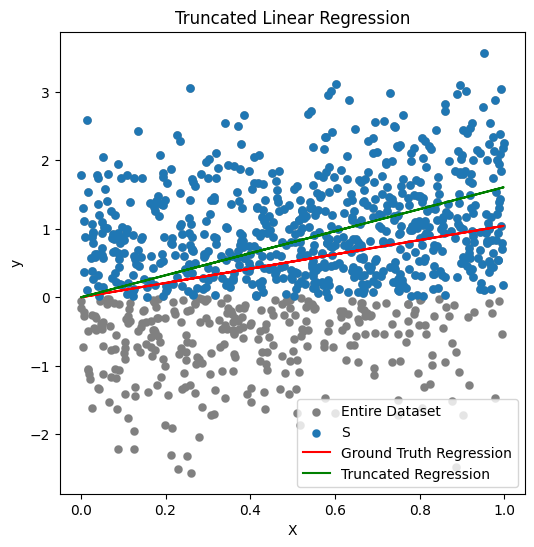

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.scatter(X, Y, linewidths=.1, color='grey', label='Entire Dataset')
ax.scatter(X_trunc, Y_trunc, linewidths=.1, label='S')
ax.plot(X.sort()[0], gt_lin_reg.predict(X.sort()[0]), color='red', label='Ground Truth Regression')
ax.plot(X.sort()[0], trunc_lin_reg.predict(X.sort()[0]), color='green', label='Truncated Regression')
ax.set_xlabel('X')
ax.set_ylabel('y')
ax.set_title('Truncated Linear Regression')
ax.legend()
plt.show()

In [8]:
import time

def generate_data(phi, num_samples, W, NOISE_VAR, W0=0, D=1, verbose=False):
    current_time_seed = int(time.time() * 1000)
    ch.manual_seed(current_time_seed)
    a, b = 0, 1
    
    x_trunc, y_trunc = ch.Tensor([]), ch.Tensor([])
    X, Y = ch.Tensor([]), ch.Tensor([])
    sampled = 0
    while x_trunc.size(0) < num_samples:
        x = (b - a) * ch.rand(num_samples, D) + a
                
        y = x @ W + W0 + (NOISE_VAR ** .5) * ch.randn(num_samples, 1)
        
        X = ch.cat([X, x])
        Y = ch.cat([Y, y])
        
        trunc_indices = phi(y).flatten().nonzero().flatten()

        y_trunc = ch.cat([y_trunc, y[trunc_indices]]) 
        x_trunc = ch.cat([x_trunc, x[trunc_indices]])
        sampled += num_samples

    alpha = x_trunc.size(0) / sampled
    if verbose: print(f'alpha: {alpha:.3f}')
    
    return x_trunc[:num_samples], y_trunc[:num_samples], alpha, X, Y

In [9]:
num_samples = 1000

def phi(X): 
    return X > 0

x_trunc, y_trunc, alpha, X, Y = generate_data(phi, num_samples, ch.ones(1, 1), 1, verbose=True)

alpha: 0.688


In [11]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 0

W = ch.ones(1, 1)

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
# NUM_SAMPLES = [100]
NUM_TRIALS = 2

results = []

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1)

        gt = LinearRegression(fit_intercept=False)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten()]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=False)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten()]))

        emp_mse_loss = mse_loss(emp_, gt_).item()

        args = Parameters({
                            'trials': 1,
                            'batch_size': 10,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
#                             'verbose': True,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                noise_var=ch.Tensor([1.0]),
                                                fit_intercept=False)
        delphi_reg.fit(x_trunc, y_trunc)

        delphi_coef_ = delphi_reg.best_coef_
        delphi_mse = mse_loss(gt_, delphi_coef_.flatten()).item()

        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'delphi_mse': delphi_mse, 
        }

        results.append(result)
            
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
trial: 1, num samples: 500
trial: 1, num samples: 1000
trial: 1, num samples: 2000
trial: 1, num samples: 3000
trial: 1, num samples: 4000
trial: 1, num samples: 5000
trial: 1, num samples: 6000
trial: 1, num samples: 7000
trial: 1, num samples: 8000
trial: 1, num samples: 9000
trial: 1, num samples: 10000
trial: 2, num samples: 100
trial: 2, num samples: 500
trial: 2, num samples: 1000
trial: 2, num samples: 2000
trial: 2, num samples: 3000
trial: 2, num samples: 4000
trial: 2, num samples: 5000
trial: 2, num samples: 6000
trial: 2, num samples: 7000
trial: 2, num samples: 8000
trial: 2, num samples: 9000
trial: 2, num samples: 10000


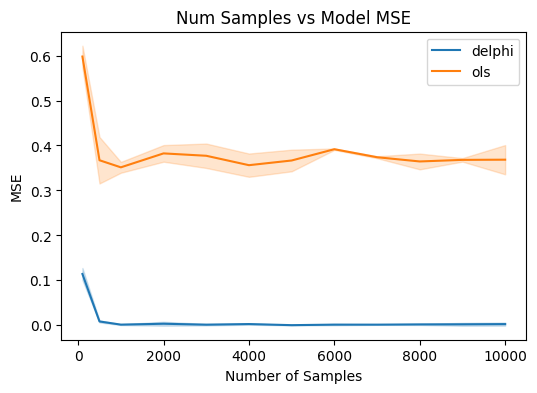

In [12]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax, label="ols")
ax.set_title('Num Samples vs Model MSE')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('MSE')

plt.show()

# 10 Dimension Truncated Regression - Varying Samples

In [13]:
def phi(x): 
    return x > 5

W = ch.ones(10, 1)
W0 = ch.ones(1, 1)
NUM_SAMPLES = 1000
x_trunc, y_trunc, alpha, X, Y = generate_data(phi, NUM_SAMPLES, W, W0, D=10, verbose=True)

alpha: 0.503


In [14]:
gt_lin_reg = LinearRegression(fit_intercept=True)
gt_lin_reg.fit(X, Y)
print(f'gt lin reg:\n {gt_lin_reg.coef_}')

trunc_lin_reg = LinearRegression(fit_intercept=True)
trunc_lin_reg.fit(x_trunc, y_trunc)
print(f'trunc lin reg W:\n {trunc_lin_reg.coef_}')

gt lin reg:
 [[1.0509894 1.0000943 0.9940939 0.9819313 0.9861834 1.0868474 0.9699459
  1.0652944 1.050484  0.9736538]]
trunc lin reg W:
 [[0.56497973 0.4929279  0.47746435 0.7162838  0.5309008  0.5375781
  0.40332726 0.49947277 0.60698247 0.52413857]]


In [15]:
gt_ = ch.from_numpy(np.concatenate([gt_lin_reg.coef_.flatten(), gt_lin_reg.intercept_]))
trunc_ = ch.from_numpy(np.concatenate([trunc_lin_reg.coef_.flatten(), trunc_lin_reg.intercept_]))

In [16]:
mse_loss(gt_, trunc_)

tensor(1.1626)

In [17]:
RAND_MATRIX = ch.randn(10, 2)

transformed_weights = ch.from_numpy(gt_lin_reg.coef_)@RAND_MATRIX
print(f'transformed weights: {transformed_weights}')

trunc_transformed_weights = ch.from_numpy(trunc_lin_reg.coef_)@RAND_MATRIX
print(f'trunc transformed weights: {trunc_transformed_weights}')

transformed_x = X@RAND_MATRIX
print(f'num samples: {transformed_x.size(0)}')
transformed_x_trunc = x_trunc@RAND_MATRIX
print(f'num truncated samples: {transformed_x_trunc.size(0)}')

transformed weights: tensor([[ 0.4375, -2.1919]])
trunc transformed weights: tensor([[ 0.1808, -0.9405]])
num samples: 3000
num truncated samples: 1000


/home/patroklos/base/lib/python3.12/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


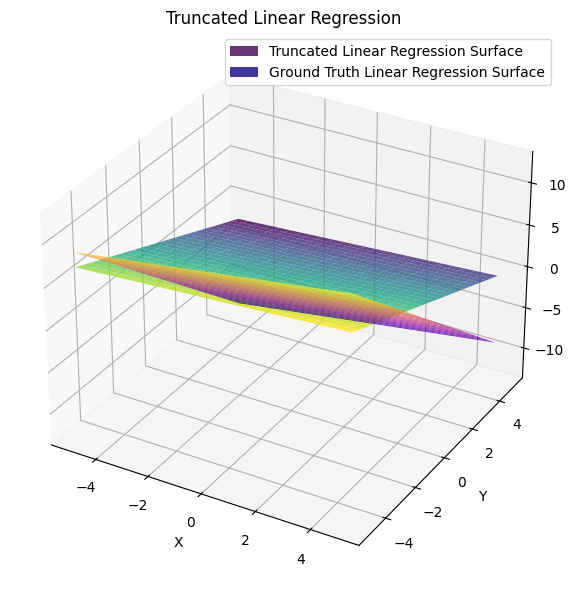

In [18]:
x_linspace = ch.linspace(-5, 5, 25)
y_linspace = ch.linspace(-5, 5, 25)
x_meshgrid, y_meshgrid = ch.meshgrid(x_linspace, y_linspace)

trunc_z = ch.zeros_like(x_meshgrid)
z = ch.zeros_like(x_meshgrid)
for i in range(len(x_linspace)): 
    for j in range(len(y_linspace)): 
        trunc_z[i, j] = trunc_transformed_weights@ch.cat([x_meshgrid[i, j][None,...], y_meshgrid[i, j][None,...]]) + ch.from_numpy(trunc_lin_reg.intercept_)
        z[i, j] = transformed_weights@ch.cat([x_meshgrid[i, j][None,...], y_meshgrid[i, j][None,...]]) + ch.from_numpy(gt_lin_reg.intercept_)

fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_subplot(111, projection='3d')
surf = ax1.plot_surface(x_meshgrid, y_meshgrid, trunc_z, cmap='viridis', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Truncated Linear Regression Surface")
surf = ax1.plot_surface(x_meshgrid, y_meshgrid, z, cmap='plasma', alpha=0.8, 
                       linewidth=0, antialiased=True, label="Ground Truth Linear Regression Surface")
# ax1.scatter(transformed_x[:,0][:100], transformed_x[:,1][:100], Y[:100], label="Entire Dataset")
# ax1.scatter(transformed_x_trunc[:,0][:100], transformed_x_trunc[:,1][:100], y_trunc[:100], label="Truncated Dataset")

ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('PREDICTION')
ax1.set_title('Truncated Linear Regression')
ax1.legend()

plt.tight_layout()
plt.show()

In [19]:
from torch.nn import MSELoss
import pandas as pd

from delphi.stats import TruncatedLinearRegression 
from delphi import oracle
from delphi.utils.helpers import Parameters

mse_loss = MSELoss()

def phi(X): 
    return X > 5

W = ch.ones(10, 1)

NUM_SAMPLES = [100, 500] + [1000*i for i in range(1, 11)]
# NUM_SAMPLES = [100]
NUM_TRIALS = 10

results = []

x_trunc_prev = None

for i in range(NUM_TRIALS): 
    for num_samples in NUM_SAMPLES: 
        print(f'trial: {i+1}, num samples: {num_samples}')
        
        x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1, D=10, verbose=True)

        gt = LinearRegression(fit_intercept=True)
        gt.fit(X, y)
        gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
        gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

        ols_trunc = LinearRegression(fit_intercept=True)
        ols_trunc.fit(x_trunc, y_trunc)
        emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))

        emp_mse_loss = mse_loss(emp_, gt_).item()

        args = Parameters({
                            'trials': 1,
                            'batch_size': 1,
                            'early_stopping': True,
                            'gradient_steps': num_samples,
                            'step_lr_gamma': 1.0,
#                             'verbose': True,
        })
        delphi_reg = TruncatedLinearRegression(args,
                                                phi,
                                                alpha, 
                                                noise_var=ch.Tensor([1.0]),
                                                fit_intercept=True)
        delphi_reg.fit(x_trunc, y_trunc)

        delphi_ = ch.concatenate([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_])

        delphi_mse = mse_loss(gt_, delphi_.flatten()).item()


        result = { 
            'num_samples': num_samples,
            'emp_mse': emp_mse_loss, 
            'delphi_mse': delphi_mse, 
        }

        results.append(result)
        
        x_trunc_prev = x_trunc
    
    
df = pd.DataFrame(results)

trial: 1, num samples: 100
alpha: 0.555
ERROR! Session/line number was not unique in database. History logging moved to new session 74
trial: 1, num samples: 500
alpha: 0.487
trial: 1, num samples: 1000
alpha: 0.506
trial: 1, num samples: 2000
alpha: 0.499
trial: 1, num samples: 3000
alpha: 0.497
trial: 1, num samples: 4000
alpha: 0.513
trial: 1, num samples: 5000
alpha: 0.496
trial: 1, num samples: 6000
alpha: 0.499
trial: 1, num samples: 7000
alpha: 0.501
trial: 1, num samples: 8000
alpha: 0.501
trial: 1, num samples: 9000
alpha: 0.498
trial: 1, num samples: 10000
alpha: 0.499
trial: 2, num samples: 100
alpha: 0.423
trial: 2, num samples: 500
alpha: 0.511
trial: 2, num samples: 1000
alpha: 0.509
trial: 2, num samples: 2000
alpha: 0.492
trial: 2, num samples: 3000
alpha: 0.501
trial: 2, num samples: 4000
alpha: 0.506
trial: 2, num samples: 5000
alpha: 0.504
trial: 2, num samples: 6000
alpha: 0.490
trial: 2, num samples: 7000
alpha: 0.509
trial: 2, num samples: 8000
alpha: 0.500
trial:

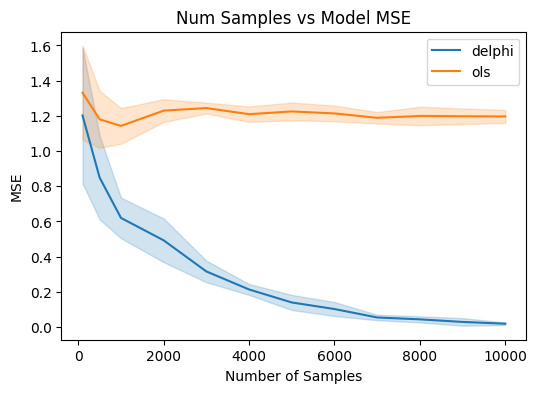

In [20]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 4)) 
sns.lineplot(data=df, x="num_samples", y="delphi_mse", estimator="mean", errorbar="sd", ax=ax, label="delphi")
sns.lineplot(data=df, x="num_samples", y="emp_mse", estimator="mean", errorbar="sd", ax=ax, label="ols")
ax.set_title('Num Samples vs Model MSE')
ax.set_xlabel('Number of Samples')
ax.set_ylabel('MSE')

plt.show()

In [128]:
D = 20
NUM_SAMPLES = 10000
# generate ground truth
NOISE_VAR = 3*ch.ones(1, 1)
W = ch.ones(1, D)
W0 = ch.ones(1, 1)
print(f"gt weight: {W}")
print(f"gt intercept: {W0}")
print(f"gt noise var: {NOISE_VAR}")

# generate data
X = ch.rand(NUM_SAMPLES, D)
y = X@W.T + W0 
noised = y + ch.sqrt(NOISE_VAR) * ch.randn(y.size(0), 1)
# generate ground-truth data
phi = oracle.Left_Regression(10*ch.ones(1))
# truncate
indices = phi(noised).nonzero()[:,0]
x_trunc, y_trunc = X[indices], noised[indices]
alpha = x_trunc.size(0) / X.size(0)
print(f'alpha: {alpha}')

gt_norm = LinearRegression()
gt_norm.fit(X, y)
gt_ = ch.from_numpy(np.concatenate([gt_norm.coef_.flatten(), gt_norm.intercept_]))

# calculate empirical noise variance for regression 
ols_trunc = LinearRegression()
ols_trunc.fit(x_trunc, y_trunc)
emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))
print(f'empirical weights: {emp_}')
emp_mse_loss = mse_loss(emp_, gt_)
print(f'emp mse loss: {emp_mse_loss}')

gt weight: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
         1., 1.]])
gt intercept: tensor([[1.]])
gt noise var: tensor([[3.]])
alpha: 0.6829
empirical weights: tensor([0.6288, 0.7156, 0.6003, 0.4977, 0.5819, 0.5494, 0.5992, 0.6702, 0.6390,
        0.4995, 0.4984, 0.5919, 0.4863, 0.6444, 0.5997, 0.5335, 0.6899, 0.5308,
        0.5991, 0.6243, 6.0422])
emp mse loss: 1.3755862712860107


In [189]:
x_trunc, y_trunc, alpha, X, y = generate_data(phi, num_samples, W, 1, D=10, verbose=True)

gt = LinearRegression(fit_intercept=True)
gt.fit(X, y)
gt_ = ch.from_numpy(np.concatenate([gt.coef_.flatten(), gt.intercept_]))
gt_noise_var = ch.from_numpy(gt.predict(X) - y.numpy()).var(0)

ols_trunc = LinearRegression(fit_intercept=True)
ols_trunc.fit(x_trunc, y_trunc)
emp_ = ch.from_numpy(np.concatenate([ols_trunc.coef_.flatten(), ols_trunc.intercept_]))

emp_mse_loss = mse_loss(emp_, gt_).item()

args = Parameters({
                    'trials': 1,
                    'batch_size': 1,
                    'early_stopping': True,
                    'gradient_steps': num_samples,
                    'step_lr_gamma': 1.0,
#                             'verbose': True,
})
delphi_reg = TruncatedLinearRegression(args,
                                        phi,
                                        alpha, 
                                        noise_var=ch.Tensor([1.0]),
                                        fit_intercept=True)
delphi_reg.fit(x_trunc, y_trunc)

delphi_ = ch.concatenate([delphi_reg.best_coef_.flatten(), delphi_reg.best_intercept_])

delphi_mse = mse_loss(gt_, delphi_.flatten()).item()

print(f'emp mse: {emp_mse_loss}')
print(f'delphi mse: {delphi_mse}')

alpha: 0.508
emp mse: 1.1605244874954224
delphi mse: 0.013210565783083439


In [188]:
x_trunc_one, y_trunc_one, alpha_one, X_one, y_one = generate_data(phi, num_samples, W, 1, D=10, verbose=True)

gt_one = LinearRegression(fit_intercept=True)
gt_one.fit(X_one, y_one)
gt_one_ = ch.from_numpy(np.concatenate([gt_one.coef_.flatten(), gt_one.intercept_]))
gt_one_noise_var = ch.from_numpy(gt_one.predict(X_one) - y_one.numpy()).var(0)

ols_trunc_one = LinearRegression(fit_intercept=True)
ols_trunc_one.fit(x_trunc_one, y_trunc_one)
ols_trunc_one_ = ch.from_numpy(np.concatenate([ols_trunc_one.coef_.flatten(), ols_trunc_one.intercept_]))

emp_one_mse_loss = mse_loss(ols_trunc_one_, gt_one_).item()

args_one = Parameters({
                    'trials': 1,
                    'batch_size': 1,
                    'early_stopping': True,
                    'gradient_steps': num_samples,
                    'step_lr_gamma': 1.0,
#                             'verbose': True,
})
delphi_reg_one = TruncatedLinearRegression(args_one,
                                        phi,
                                        alpha_one, 
                                        noise_var=ch.Tensor([1.0]),
                                        fit_intercept=True)
delphi_reg_one.fit(x_trunc_one, y_trunc_one)

delphi_one_ = ch.concatenate([delphi_reg_one.best_coef_.flatten(), delphi_reg_one.best_intercept_])

delphi_one_mse = mse_loss(gt_one_, delphi_one_.flatten()).item()

print(f'emp mse: {emp_one_mse_loss}')
print(f'delphi mse: {delphi_one_mse}')

alpha: 0.500
emp mse: 1.2135404348373413
delphi mse: 0.0284893736243248


In [190]:
x_trunc

tensor([[0.6354, 0.1523, 0.5825,  ..., 0.7269, 0.9952, 0.3472],
        [0.7717, 0.3570, 0.4270,  ..., 0.5188, 0.8169, 0.3988],
        [0.5283, 0.6889, 0.7178,  ..., 0.5978, 0.5182, 0.8462],
        ...,
        [0.3930, 0.8473, 0.7188,  ..., 0.5179, 0.2286, 0.3823],
        [0.7220, 0.4216, 0.2634,  ..., 0.9127, 0.0752, 0.1631],
        [0.0163, 0.8379, 0.6711,  ..., 0.9168, 0.3982, 0.6126]])

In [191]:
x_trunc_one

tensor([[0.8088, 0.5163, 0.4953,  ..., 0.8636, 0.0262, 0.6131],
        [0.5522, 0.8938, 0.4517,  ..., 0.5968, 0.0033, 0.2727],
        [0.7981, 0.5427, 0.3763,  ..., 0.3895, 0.9989, 0.8439],
        ...,
        [0.1841, 0.4585, 0.8531,  ..., 0.5894, 0.0754, 0.3567],
        [0.3072, 0.7998, 0.9718,  ..., 0.6598, 0.3750, 0.6926],
        [0.7797, 0.9773, 0.5297,  ..., 0.6992, 0.0461, 0.5801]])